### Imports and Ray Initialization

In [1]:
import ray
import os
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from agamoo_ray import AGAMOO, Evaluator
from agamoo_ray.players import ClonalSelection
from agamoo_ray.objectives.treproblems import RE33

from pymoo.indicators.hv import HV
from pygmo import hypervolume

def normalize(values, fmin, fmax):
    return (values - fmin) / (fmax - fmin)

# Initialize the Ray distributed execution engine
os.environ["RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO"] = "0"
if not ray.is_initialized():
    ray.init()

2026-04-21 18:54:34,742	INFO worker.py:1998 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 


### Experiment Definition

In [2]:
max_eval = 10000
max_front = 100
change_iter = 1
next_iter = -1
log_freq = 5
npop = 25
player_parm = { "nclone": 12, "mutate_args": [0.2, 0.85, 0.005], 'sup': 0.0, 'strategy': 'base'}

In [3]:
nobj = 3
objs = []
for i in range(3):
    obj = eval(f'RE33({i}, obj={i+1})')
    objs.append(obj)
nvar = obj.n_var
bounds = obj.bounds

#### Blocking mode, DVA: random

In [4]:
np.random.seed(41)
agamoo = AGAMOO(max_eval, change_iter, next_iter, max_front, assign_gens='random', log_freq=log_freq)
storage = agamoo.create_storage(nvar, nobj, num_cpus=nobj)
evaluators = [Evaluator.options(num_cpus=1).remote(objs) for _ in range(len(objs)-1)]
players = [ClonalSelection.options(num_cpus=1).remote(i, npop, player_parm, obj, storage, gens='pattern', exchange='front_sup') for i, obj in zip(range(nobj), objs)]
agamoo.init_players(players, evaluators)
agamoo.start_optimize(tqdm_disable=False)
res1=agamoo.get_results()
hist1 = agamoo.get_history()

  0%|          | 0/10000 [00:00<?, ?eval/s]

#### Background mode, DVA: adaptive linear (correlation-based)

In [5]:
np.random.seed(41)
agamoo = AGAMOO(max_eval, change_iter, next_iter, max_front, assign_gens='adaptive_linear', log_freq=log_freq)
storage = agamoo.create_storage(nvar, nobj, num_cpus=nobj)
evaluators = [Evaluator.options(num_cpus=1).remote(objs) for _ in range(len(objs)-1)]
players = [ClonalSelection.options(num_cpus=1).remote(i, npop, player_parm, obj, storage, gens='pattern', exchange='front_sup') for i, obj in zip(range(nobj), objs)]
agamoo.init_players(players, evaluators)

agamoo.start_optimize(tqdm_disable=True, background=True)
while True:
    status = agamoo.get_status()
    print(f"Progress: {status['evaluations']} evaluations...")
    if status['stop_flag']:
        print('Stop')
        break
    time.sleep(5)
res2=agamoo.get_results()
hist2 = agamoo.get_history()

Progress: [0. 0. 0.] evaluations...
Progress: [12113.  9320.  2648.] evaluations...
Progress: [23995. 18438.  5398.] evaluations...
Progress: [35573. 27706.  8046.] evaluations...
Progress: [44428. 34488. 10108.] evaluations...
Stop


### Pareto front comparison

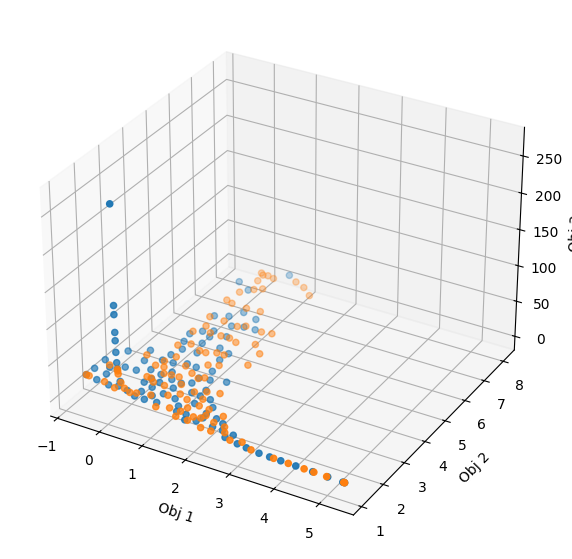

In [6]:
f_eval1 = res1['front_eval']
f_eval2 = res2['front_eval']
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(f_eval1[:, 0], f_eval1[:, 1], f_eval1[:, 2])
sc = ax.scatter(f_eval2[:, 0], f_eval2[:, 1], f_eval2[:, 2])
ax.set_xlabel('Obj 1')
ax.set_ylabel('Obj 2')
ax.set_zlabel('Obj 3')
plt.show()

### Convergence plots of the HV indicator

In [7]:
fmin, fmax = np.array([-0.721525, 1.13907204, 0.0]), np.array([5.30670000e+00, 9.06681054e+00, 4.32347058e+09])
ref_point = np.ones(3)*1.1
data1 = {'Iter': [], 'Neval': [], 'Time': [], 'HV': []}
for i in range(1,len(hist1)):
    data1['Iter'].append(hist1[i]['iteration'])
    data1['Neval'].append(np.min(hist1[i]['nfe_array']))
    data1['Time'].append(hist1[i]['wall_clock_time']/1.e9)
    front_eval = hist1[i]['front_eval']
    if hist1[i]['iteration'] == 0:
        data1['HV'].append(0.0)
    else:
        nfront_eval = normalize(front_eval, fmin, fmax)
        mask = np.any(nfront_eval>=1.1, axis=1)
        nfront_eval = nfront_eval[np.logical_not(mask)]
        if len(nfront_eval)<1:
            data1['HV'].append(0.0)
        else:
            hv = hypervolume(nfront_eval).compute(ref_point)
            data1['HV'].append(hv)

data2 = {'Iter': [], 'Neval': [], 'Time': [], 'HV': []}
for i in range(1,len(hist2)):
    data2['Iter'].append(hist2[i]['iteration'])
    data2['Neval'].append(np.min(hist2[i]['nfe_array']))
    data2['Time'].append(hist2[i]['wall_clock_time']/1.e9)
    front_eval = hist2[i]['front_eval']
    if hist2[i]['iteration'] == 0:
        data2['HV'].append(0.0)
    else:
        nfront_eval = normalize(front_eval, fmin, fmax)
        mask = np.any(nfront_eval>=1.1, axis=1)
        nfront_eval = nfront_eval[np.logical_not(mask)]
        if len(nfront_eval)<1:
            data2['HV'].append(0.0)
        else:
            hv = hypervolume(nfront_eval).compute(ref_point)
            data2['HV'].append(hv)

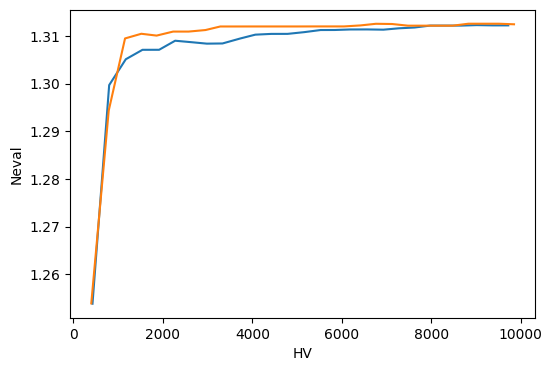

In [8]:
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
sc1 = ax.plot(data1['Neval'], data1['HV'])
sc2 = ax.plot(data2['Neval'], data2['HV'])
ax.set_xlabel('HV')
ax.set_ylabel('Neval')
plt.show()

### Analysis of variable assignment

DVA: random

In [9]:
run_patterns = []
for i in range(1, len(hist1)):
    run_patterns.extend(hist1[i]['patterns'])
P_r = np.stack(run_patterns)
_, O, V = P_r.shape

#Assignment probability (% of time)
prob = P_r.mean(axis=0) * 100
df_probs = pd.DataFrame(prob, index=[f'Obj_{i}' for i in range(O)], columns=[f'Var_{j}' for j in range(V)]).round(2)

print("--- Percentage of time variable assigned to objective [%] ---")
print(df_probs)
print("\n")

#Average number of variables held by a player
vars_per_player = P_r.sum(axis=2).mean(axis=0)
df_players = pd.DataFrame({'Controlled Genes Count': vars_per_player}, index=[f'Obj_{i}' for i in range(O)]).round(2)

print("--- Average player wealth (number of controlled genes) ---")
print(df_players)
print("\n")

#Sharing and exclusion analysis
owners_r = P_r.sum(axis=1) 
exclusive = (owners_r == 1).mean(axis=0) * 100
shared = (owners_r > 1).mean(axis=0) * 100
unassigned = (owners_r == 0).mean(axis=0) * 100

df_vars = pd.DataFrame({'Exclusive [%]': exclusive,'Shared [%]': shared, 'Unassigned [%]': unassigned},
                       index=[f'Var_{j}' for j in range(V)]).round(2)

print("--- Conflict statistics for individual variables ---")
print(df_vars)
print("\n")

--- Percentage of time variable assigned to objective [%] ---
       Var_0  Var_1  Var_2  Var_3
Obj_0  28.98  34.03  36.13  29.45
Obj_1  39.24  30.69  37.68  33.95
Obj_2  31.78  35.28  26.18  36.60


--- Average player wealth (number of controlled genes) ---
       Controlled Genes Count
Obj_0                    1.29
Obj_1                    1.42
Obj_2                    1.30


--- Conflict statistics for individual variables ---
       Exclusive [%]  Shared [%]  Unassigned [%]
Var_0          100.0         0.0             0.0
Var_1          100.0         0.0             0.0
Var_2          100.0         0.0             0.0
Var_3          100.0         0.0             0.0




DVA: adaptive linear (correlation-based)

In [10]:
run_patterns = []
for i in range(1, len(hist2)):
    run_patterns.extend(hist2[i]['patterns'])
P_r = np.stack(run_patterns)
_, O, V = P_r.shape

#Assignment probability (% of time)
prob = P_r.mean(axis=0) * 100
df_probs = pd.DataFrame(prob, index=[f'Obj_{i}' for i in range(O)], columns=[f'Var_{j}' for j in range(V)]).round(2)

print("--- Percentage of time variable assigned to objective [%] ---")
print(df_probs)
print("\n")

#Average number of variables held by a player
vars_per_player = P_r.sum(axis=2).mean(axis=0)
df_players = pd.DataFrame({'Controlled Genes Count': vars_per_player}, index=[f'Obj_{i}' for i in range(O)]).round(2)

print("--- Average player wealth (number of controlled genes) ---")
print(df_players)
print("\n")

#Sharing and exclusion analysis
owners_r = P_r.sum(axis=1) 
exclusive = (owners_r == 1).mean(axis=0) * 100
shared = (owners_r > 1).mean(axis=0) * 100
unassigned = (owners_r == 0).mean(axis=0) * 100

df_vars = pd.DataFrame({'Exclusive [%]': exclusive,'Shared [%]': shared, 'Unassigned [%]': unassigned},
                       index=[f'Var_{j}' for j in range(V)]).round(2)

print("--- Conflict statistics for individual variables ---")
print(df_vars)
print("\n")

--- Percentage of time variable assigned to objective [%] ---
       Var_0  Var_1  Var_2  Var_3
Obj_0  36.68  97.12  31.81  32.99
Obj_1  35.28  32.03  99.19  58.82
Obj_2  28.04  36.46  35.50  34.54


--- Average player wealth (number of controlled genes) ---
       Controlled Genes Count
Obj_0                    1.99
Obj_1                    2.25
Obj_2                    1.35


--- Conflict statistics for individual variables ---
       Exclusive [%]  Shared [%]  Unassigned [%]
Var_0         100.00        0.00             0.0
Var_1          34.39       65.61             0.0
Var_2          33.51       66.49             0.0
Var_3          73.65       26.35             0.0


